#Creating machine learning model for breast cancer dataset

##Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn import datasets
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score,recall_score, f1_score


##Loading Data

In [2]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)  # all input features as DataFrame
y = data.target  #target output is 0 or 1(benign or malignant)
X.head()  #shows first 5 rows

# data.data is numerical values of features and data.feature_names is names of each feature

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
print(data.target_names)  #Here its confirmed that benign=1, malignant=0.Thus no further encoding

['malignant' 'benign']


##Data Preprocessing

In [4]:
X.isnull().sum() #checking missing values

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


In [5]:
X.info()  #display basic information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

##- No missing values ,so no need to handle

#Exploratory Data Analysis(EDA)

##Data Overview

In [6]:
print("shape", X.shape)
print("\ncolumns", X.columns)
print("\ndatatypes", X.dtypes)
print("\nsummary statistics\n", X.describe())  #gives summary statistics

shape (569, 30)

columns Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='object')

datatypes mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry          

##Heatmap

In [7]:
selected_features = list(X.columns[3:7])  #selecting 4 features from the dataset(columns 3:6 ,excludes 7)
X = X[selected_features]

Index(['mean area', 'mean smoothness', 'mean compactness', 'mean concavity'], dtype='object')


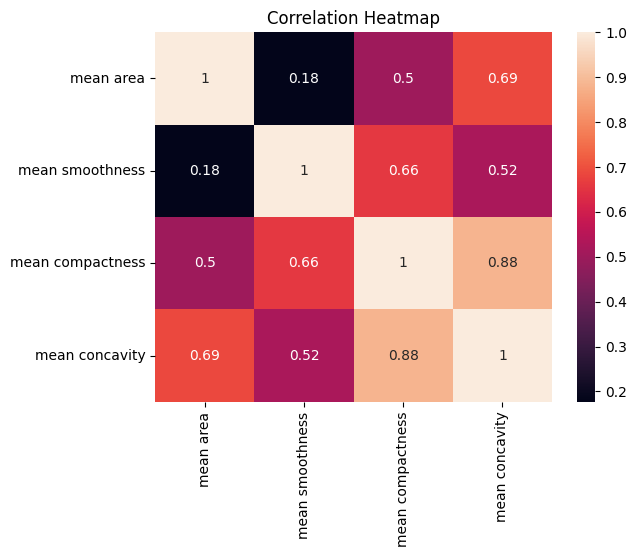

In [8]:
sns.heatmap(X.corr(), annot=True) #heatmap to get correlation btw selected features
plt.title('Correlation Heatmap')  #adding title
plt.show
print(X.columns)  #printing columns

- highest correlation is 0.88(btw mean compactness and concavity)
- lowest is 0.18(btw mean area and mean smoothness)
- 1 is self-correlation so not taken as highest

##Histogram(used to visualize distribution of numerical data)

In [9]:
num_df = X.select_dtypes(include="number")
cat_df = X.select_dtypes(include="object")

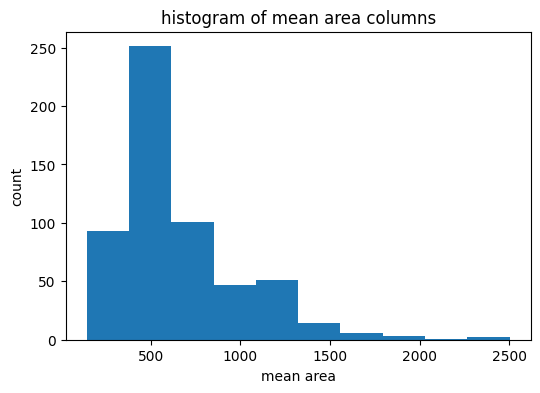

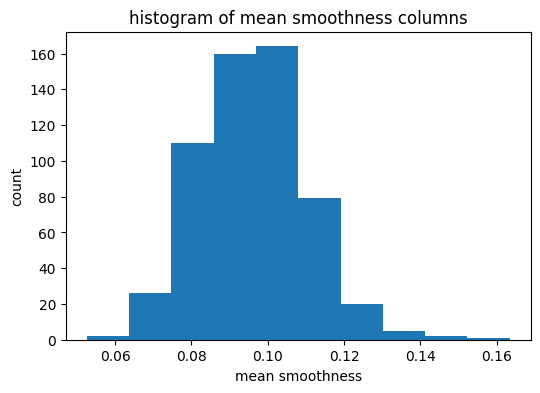

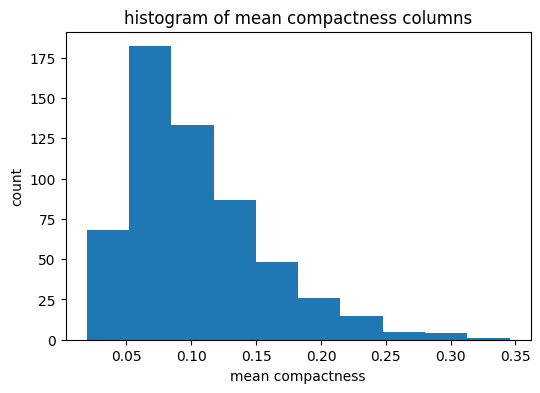

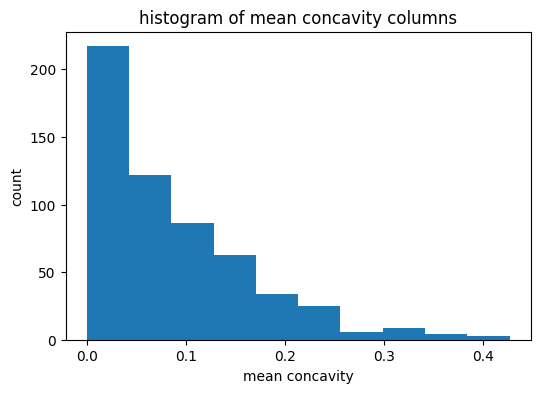

In [10]:
num_cols = ['mean area','mean smoothness','mean compactness','mean concavity']  #selecting 4 features used in web app
for col in num_cols:
  plt.figure(figsize=(6,4))  #sets size to 6inches wide and 4inches tall
  plt.hist(num_df[col])  #plot histogram to show distribution of values in column
  plt.title("histogram of {} columns".format(col)) #title gets printed in this format
  plt.xlabel(col)
  plt.ylabel("count")
  plt.show()

- First graph has peak around 500 which means most data points have mean area arnd 500,with fewer points having larger mean area
- Second graph peaks around 0.10 with fewer values deviating from central value
- Third graph shows most data points have mean compactness around 0.05 to 0.1 and freq declines as mean compactness increases
- Last graph have mean concavity around 0 to 0.05 and freq declines as mean concavity increases

##Outliers

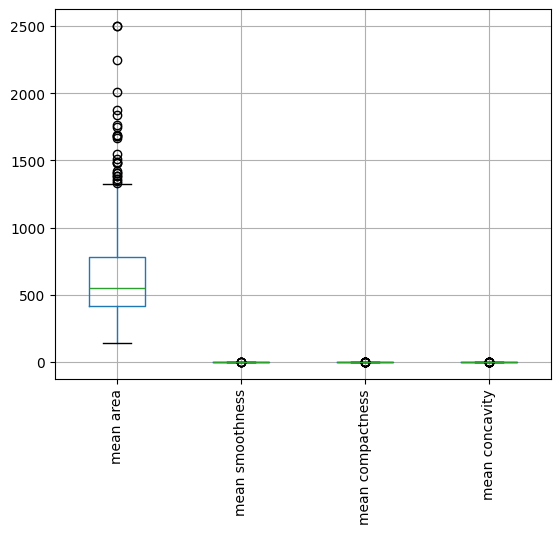

In [11]:
num_cols = ['mean area','mean smoothness','mean compactness','mean concavity']
num_df[num_cols].boxplot()
plt.xticks(rotation=90)
plt.show()

- Boxplot clearly shows outliers, especially in:
      mean area:outliers abv 2000
      minor outliers exist in other features
- Here handling is the best option instead of removing because mean area is one of our input in web app      

##Handling outliers

In [12]:
for col in num_cols:
  q1 = num_df[col].quantile(0.25)
  q3 = num_df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5 * iqr
  upper_bound = q3 + 1.5 * iqr
  num_df[col] = num_df[col].clip(lower_bound, upper_bound)  #replaces outliers with boundary values

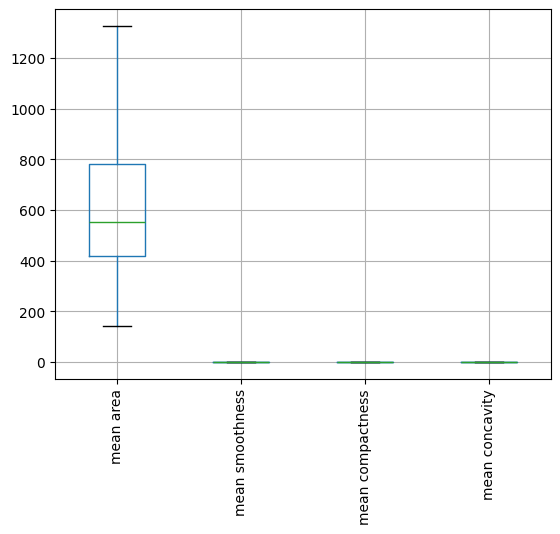

In [13]:
# rechecking boxplot
num_df[num_cols].boxplot()
plt.xticks(rotation=90)
plt.show()

##Scaling

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# used StandardScaler to ensure that all features are on the same scale

##Splitting the data

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Modelling

##Finding the best algorithm among three of them
- using Logistic Regression, Naive Bayes,KNN

In [16]:
from sklearn.linear_model import LogisticRegression  #logistic regression
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [17]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')   #model building
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

Accuracy: 0.9298245614035088
Precision: 0.9331867752920384
Recall: 0.9298245614035088
F1 Score: 0.928615457562826


In [18]:
from sklearn.neighbors import KNeighborsClassifier  #KNN
model = KNeighborsClassifier()
model.fit(X_train, y_train)

KNeighborsClassifier()

In [19]:
knn_y_pred = model.predict(X_test)
knn_test_accuracy = accuracy_score(y_test, knn_y_pred)
knn_test_precision = precision_score(y_test, knn_y_pred, average='weighted')
knn_test_recall = recall_score(y_test, knn_y_pred, average='weighted')
knn_test_f1 = f1_score(y_test, knn_y_pred, average='weighted')

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

Accuracy: 0.9298245614035088
Precision: 0.9331867752920384
Recall: 0.9298245614035088
F1 Score: 0.928615457562826


In [20]:
naive_bayes = GaussianNB()  #Naive Bayes
naive_bayes.fit(X_train, y_train)

GaussianNB()

In [21]:
y_pred = naive_bayes.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred, average='weighted')
test_recall = recall_score(y_test, y_pred, average='weighted')
test_f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

Accuracy: 0.9298245614035088
Precision: 0.9331867752920384
Recall: 0.9298245614035088
F1 Score: 0.928615457562826


##Model Evaluation

In [22]:
metrics = {
    'Model': ['Logistic Regression', 'KNN', 'Naive Bayes'],
    'Test Accuracy': [accuracy, knn_test_accuracy, test_accuracy],
    'Test Precision': [precision, knn_test_precision, test_precision],
    'Test Recall': [recall, knn_test_recall, test_recall],
    'Test F1 Score': [f1, knn_test_f1, test_f1]
}

metrics_df = pd.DataFrame(metrics)
metrics_df

,Model,Test Accuracy,Test Precision,Test Recall,Test F1 Score
0,Logistic Regression,0.929825,0.933187,0.929825,0.928615
1,KNN,0.921053,0.922784,0.921053,0.919959
2,Naive Bayes,0.938596,0.940905,0.938596,0.937746


#Training the model

##Importing libraries

In [23]:
import pandas as pd
import numpy as np
import tensorflow as tf


In [24]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  #to compute and apply scaling
X_test = scaler.transform(X_test)  #used on test data

##Model Building

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input

##Model Architecture

In [26]:
model = Sequential()  #initializing
model.add(Input(shape=(4,))) #shape is 4 coz we only require 4 input features
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  #sigmoid for binary classification

##Training

In [27]:
from tensorflow.keras.metrics import Precision, Recall, Accuracy
model.compile(optimizer='adam',
              loss='binary_crossentropy',  #binary classification
              metrics=['accuracy'])

In [28]:
history = model.fit(X_train,  #train features
                    y_train,
                    epochs=100, #no.of training iteration
                    validation_data=(X_test, y_test))

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.2264 - loss: 0.8262 - val_accuracy: 0.3070 - val_loss: 0.7851
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3495 - loss: 0.7654 - val_accuracy: 0.4649 - val_loss: 0.7353
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5341 - loss: 0.7210 - val_accuracy: 0.6228 - val_loss: 0.6978
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6242 - loss: 0.6857 - val_accuracy: 0.6228 - val_loss: 0.6662
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6242 - loss: 0.6544 - val_accuracy: 0.6228 - val_loss: 0.6360
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6374 - loss: 0.6221 - val_accuracy: 0.6404 - val_loss: 0.6014
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6659 - loss: 0.5844 - val_accuracy: 0.6754 - val_loss: 0.5605
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7209 - loss: 0.5414 - val_accuracy: 0.7456 - 

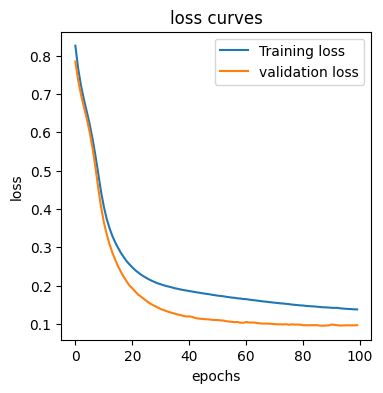

In [29]:
import matplotlib.pyplot as plt
plt.figure(figsize=(4, 4))  #plot figure size
plt.plot(history.history['loss'], label='Training loss') #plot training loss
plt.plot(history.history['val_loss'], label='validation loss') #plot validation loss
plt.title('loss curves')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show() #to display graph

- The graph says both loss decrease sharply in initial epochs
- Graph performs well on both training and validation datasets

In [30]:
model.save('breast cancer.keras')  #saving the model